In [199]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [200]:
!pip install -U scikit-posthocs

In [201]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Forecast')

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils.plot_dashes as plot_dashes
import scikit_posthocs as sp

from scipy.stats import friedmanchisquare
from conf.processing import DataProcessing
from utils import genetic_algorithm as gen_alg
from models import ann_models, kernel_method, tree_based_ensemble as tree_based

pd.set_option('display.float_format', '{:.6f}'.format)

Dataset

In [202]:
all_results = []
all_runs = []
ga_runs = []

def get_file():

    file_path = '/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets'

    for f in os.listdir(file_path):
        full_path = os.path.join(file_path, f)

        yield full_path

for f in get_file():

    dataset = pd.read_csv(f, sep='\t', decimal='.')
    raw_data = DataProcessing(dataset, n_lags=5)
    prep_data = raw_data.prepare_data()

    mlp = ann_models.MLP()
    results_MLP = mlp.train(prep_data)
    MLP_forecast_v = np.array(results_MLP['pred_valid'])
    MLP_forecast = np.array(results_MLP['pred_test_denom'])
    
    scn = ann_models.GridSCN()
    results_SCN = scn.train(prep_data)
    SCN_forecast_v = np.array(results_SCN['pred_valid'])
    SCN_forecast = np.array(results_SCN['pred_test'])

    elm = ann_models.GridELM()
    results_ELM = elm.train(prep_data)
    ELM_forecast_v = np.array(results_ELM['pred_valid'])
    ELM_forecast = np.array(results_ELM['pred_test_denom'])

    svr = kernel_method.SVM()
    results_SVR = svr.train(prep_data)
    SVR_forecast_v = np.array(results_SVR['pred_valid'])
    SVR_forecast = np.array(results_SVR['pred_test'])
    
    rf = tree_based.RF()
    results_RF = rf.train(prep_data)
    RF_forecast_v = np.array(results_RF['pred_valid'])
    RF_forecast = np.array(results_RF['pred_test'])

    gb = tree_based.GBoosting()
    results_GB = gb.train(prep_data)
    GB_forecast_v = np.array(results_GB['pred_valid'])
    GB_forecast = np.array(results_GB['pred_test'])

    P_v = np.column_stack(
        (
            MLP_forecast_v.copy(), 
            SCN_forecast_v.copy(),
            ELM_forecast_v.copy(), 
            SVR_forecast_v.copy(), 
            RF_forecast_v.copy(), 
            GB_forecast_v.copy()
        )
    )

    P = np.column_stack(
        (
            MLP_forecast.copy(), 
            SCN_forecast.copy(),
            ELM_forecast.copy(), 
            SVR_forecast.copy(), 
            RF_forecast.copy(), 
            GB_forecast.copy()
        )
    )
    
    for x in range(30):
        
        ga = gen_alg.GeneticAlgorithm()
        
        ga_result = ga.execute(P_v, prep_data['target_valid'])

        y_hat = P @ ga_result['best_ind']
        ga_metrics = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat)
        ga_runs.append({

            'Dataset': os.path.basename(f),
            'Run': x,

            'MSE': ga_metrics['MSE'],
            'RMSE': ga_metrics['RMSE'],
            'MAE': ga_metrics['MAE'],
            'MAPE': ga_metrics['MAPE'],

            'Weights': ga_result['best_ind'],
            'Fitness': ga_result['best_fitness'],
            'Fitness_Curve': ga_result['fitness_curve']

        })
        
    weights = np.array([1/6]*6)
    ensemble_mean = P @ weights

    MLP = plot_dashes.get_metrics_error(prep_data['target_test'], MLP_forecast)
    SCN = plot_dashes.get_metrics_error(prep_data['target_test'], SCN_forecast)
    ELM = plot_dashes.get_metrics_error(prep_data['target_test'], ELM_forecast)
    SVR = plot_dashes.get_metrics_error(prep_data['target_test'], SVR_forecast)
    RF = plot_dashes.get_metrics_error(prep_data['target_test'], RF_forecast)
    GB = plot_dashes.get_metrics_error(prep_data['target_test'], GB_forecast)
    EMEAN = plot_dashes.get_metrics_error(prep_data['target_test'], ensemble_mean)
    GA = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat)

    all_results.append({
        'dataset': os.path.basename(f),
        'MLP': MLP,
        'SCN': SCN,
        'ELM': ELM,
        'SVR': SVR,
        'RF': RF,
        'GB': GB,
        'EMEAN': EMEAN,
        'GA': GA
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'MLP',
        'runs': results_MLP['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'SCN',
        'runs': results_SCN['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'ELM',
        'runs': results_ELM['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'SVR',
        'runs': results_SVR['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'RF',
        'runs': results_RF['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'GB',
        'runs': results_GB['lst_results']
    })
    

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [203]:
df_results = pd.DataFrame(all_results)
df_runs = pd.DataFrame(all_runs)

In [204]:
# 1. Tabela Principal (MSE, RMSE, MAE e MAPE)
rows = []

for _, row in df_results.iterrows():

    dataset = row['dataset']

    for model in ['MLP','SCN','ELM','SVR','RF','GB', 'EMEAN', 'GA']:
        metrics = row[model]
        rows.append({

            'Dataset': dataset,
            'Model': model,

            'MSE': metrics['MSE'],
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE': metrics['MAPE']

        })

df_metrics = pd.DataFrame(rows)

In [205]:
df_metrics

,Dataset,Model,MSE,RMSE,MAE,MAPE
0,airlines.txt,MLP,3677.685524,60.643924,46.947457,0.099546
1,airlines.txt,SCN,31902.329268,178.612232,116.650433,0.281257
2,airlines.txt,ELM,12656.480049,112.501022,90.242150,0.202286
3,airlines.txt,SVR,15222.424587,123.379190,105.387674,0.222434
4,airlines.txt,RF,22154.295907,148.843192,127.779707,0.269653
5,airlines.txt,GB,20154.553053,141.966732,120.217282,0.252672
6,airlines.txt,EMEAN,12208.939204,110.494069,94.927464,0.204741
7,airlines.txt,GA,10708.470055,103.481738,80.074844,0.179821
8,coloradoRiver.txt,MLP,0.297891,0.545794,0.407296,1.312045
9,coloradoRiver.txt,SCN,0.375007,0.612378,0.416364,1.064376


In [206]:
# 2. Média das Métricas por Modelo
df_metrics.groupby('Model')[['MSE','RMSE','MAE','MAPE']].mean()

,MSE,RMSE,MAE,MAPE
Model,,,,
ELM,129326.682664,206.418145,166.634874,0.449017
EMEAN,149558.238961,219.693686,170.355989,0.446379
GA,136210.242738,209.273524,163.594383,0.417714
GB,213095.889385,264.281201,216.764766,0.676636
MLP,139184.519131,201.782364,152.773564,0.592510
RF,163754.746141,236.826305,182.850561,0.433501
SCN,166724.899031,244.584261,176.891890,0.701477
SVR,407780.949493,349.343362,264.713658,0.451048


In [207]:
# 3. Ranking dos Modelos
ranking = []

for dataset in df_metrics['Dataset'].unique():

    temp = df_metrics[df_metrics['Dataset']==dataset]
    temp = temp.sort_values('MSE')
    temp['Rank'] = range(1,len(temp)+1)
    ranking.append(temp)

df_rank = pd.concat(ranking)

In [208]:
df_rank

,Dataset,Model,MSE,RMSE,MAE,MAPE,Rank
0,airlines.txt,MLP,3677.685524,60.643924,46.947457,0.099546,1
7,airlines.txt,GA,10708.470055,103.481738,80.074844,0.179821,2
6,airlines.txt,EMEAN,12208.939204,110.494069,94.927464,0.204741,3
2,airlines.txt,ELM,12656.480049,112.501022,90.242150,0.202286,4
3,airlines.txt,SVR,15222.424587,123.379190,105.387674,0.222434,5
5,airlines.txt,GB,20154.553053,141.966732,120.217282,0.252672,6
4,airlines.txt,RF,22154.295907,148.843192,127.779707,0.269653,7
1,airlines.txt,SCN,31902.329268,178.612232,116.650433,0.281257,8
10,coloradoRiver.txt,ELM,0.271264,0.520830,0.267377,0.358685,1
14,coloradoRiver.txt,EMEAN,0.274291,0.523728,0.346311,0.743797,2


In [209]:
df_rank.groupby('Model')['Rank'].mean()

,Rank
Model,
ELM,3.250000
EMEAN,2.500000
GA,2.250000
GB,6.750000
MLP,3.500000
RF,5.750000
SCN,6.250000
SVR,5.750000


In [210]:
# 4. Média e Desvio das Execuções - Valores NaN

rows=[]

for _,row in df_runs.iterrows():

    for i,mse in enumerate(row['runs']):

        rows.append({

            'Dataset':row['dataset'],
            'Model':row['model'],
            'Run':i,
            'MSE':mse

        })

df_runs_expand = pd.DataFrame(rows)

df_runs_expand.groupby(
    ['Dataset','Model']
)['MSE'].agg(
    ['mean','std','min','max']
)

mean          std            min  \
Dataset           Model                                              
airlines.txt      ELM     14695.848136  2149.682714   12656.480049   
                  GB      20172.847557    38.575053   20154.553053   
                  MLP      4045.443629  1093.692864    3677.685524   
                  RF      22549.442353   540.641534   22154.295907   
                  SCN     31902.329268          NaN   31902.329268   
                  SVR     15222.424587          NaN   15222.424587   
coloradoRiver.txt ELM         0.266152     0.003051       0.262547   
                  GB          0.374943     0.000000       0.374943   
                  MLP         0.318504     0.029437       0.277628   
                  RF          0.482189     0.013456       0.477933   
                  SCN         0.375007          NaN       0.375007   
                  SVR         0.315603          NaN       0.315603   
lynx.txt          ELM    516996.972187 39060.873495  504644.839423   
                  GB     832734.800840  1078.090296  832223.417711   
                  MLP    557553.219704 28530.463384  507075.470156   
                  RF     683606.410090 50378.316588  632859.165130   
                  SCN    634991.835272          NaN  634991.835272   
                  SVR   1615895.979524          NaN 1615895.979524   
melbmin.txt       ELM         5.134803     0.010790       5.113944   
                  GB          5.212669     0.001766       5.211832   
                  MLP         5.100387     0.022292       5.079239   
                  RF          5.045595     0.000000       5.045595   
                  SCN         5.056576          NaN       5.056576   
                  SVR         5.078260          NaN       5.078260   

                                   max  
Dataset           Model                 
airlines.txt      ELM     16735.216223  
                  GB      20247.567894  
                  MLP      7152.880000  
                  RF      23652.130469  
                  SCN     31902.329268  
                  SVR     15222.424587  
coloradoRiver.txt ELM         0.271264  
                  GB          0.374943  
                  MLP         0.351731  
                  RF          0.520486  
                  SCN         0.375007  
                  SVR         0.315603  
lynx.txt          ELM    628166.167062  
                  GB     834780.333355  
                  MLP    587937.584708  
                  RF     740547.933896  
                  SCN    634991.835272  
                  SVR   1615895.979524  
melbmin.txt       ELM         5.139920  
                  GB          5.216019  
                  MLP         5.121536  
                  RF          5.045595  
                  SCN         5.056576  
                  SVR         5.078260

In [211]:
# 5. Organizar o GA

df_ga = pd.DataFrame(ga_runs)

In [212]:
df_ga.groupby('Dataset')['MSE'].mean()

,MSE
Dataset,
airlines.txt,13301.912386
coloradoRiver.txt,0.279606
lynx.txt,538473.423659
melbmin.txt,5.028079


In [213]:
df_ga.groupby('Dataset')['MSE'].std()

,MSE
Dataset,
airlines.txt,2396.796023
coloradoRiver.txt,0.004064
lynx.txt,10410.049955
melbmin.txt,0.005695


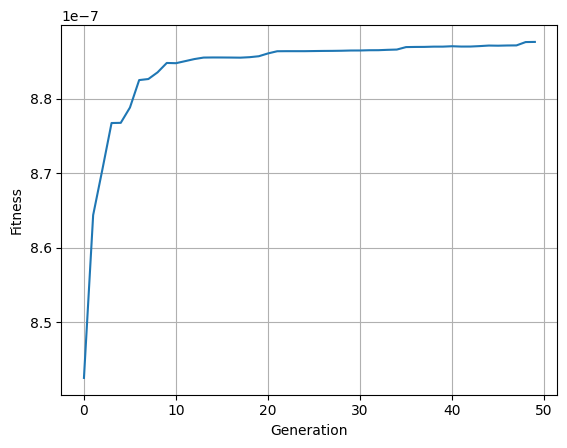

In [214]:
# 7. Curva de Convergência

ga_result['fitness_curve']
plt.plot(ga_result['fitness_curve'])
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid()
plt.show()

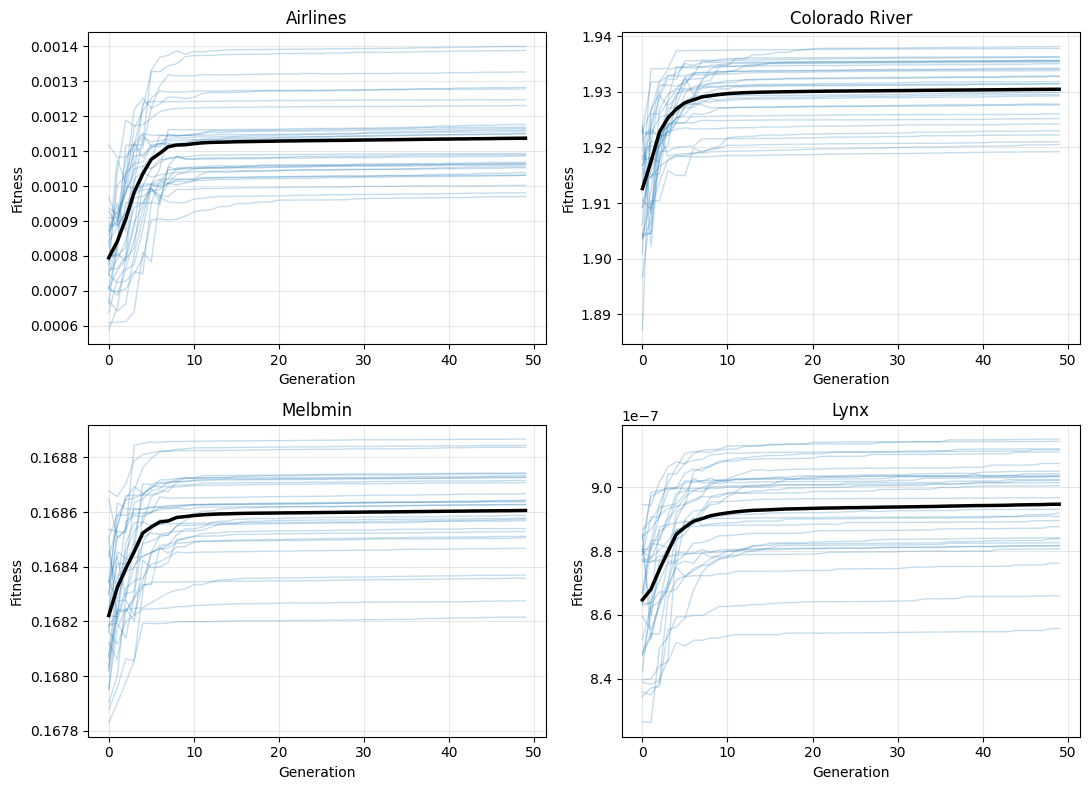

In [215]:
datasets = [
    "airlines.txt",
    "coloradoRiver.txt",
    "melbmin.txt",
    "lynx.txt"
]

titles = [
    "Airlines",
    "Colorado River",
    "Melbmin",
    "Lynx"
]

fig, axes = plt.subplots(2, 2, figsize=(11,8))

axes = axes.flatten()

for ax, dataset, title in zip(axes, datasets, titles):

    fitness_curves = np.array([
        run["Fitness_Curve"]
        for run in ga_runs
        if run["Dataset"] == dataset
    ])

    mean_curve = fitness_curves.mean(axis=0)

    # Todas as execuções
    for curve in fitness_curves:
        ax.plot(
            curve,
            color='tab:blue',
            alpha=0.25,
            linewidth=1
        )

    # Média
    ax.plot(
        mean_curve,
        color='black',
        linewidth=2.5,
        label='Average'
    )

    ax.set_title(title)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "ga_convergence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

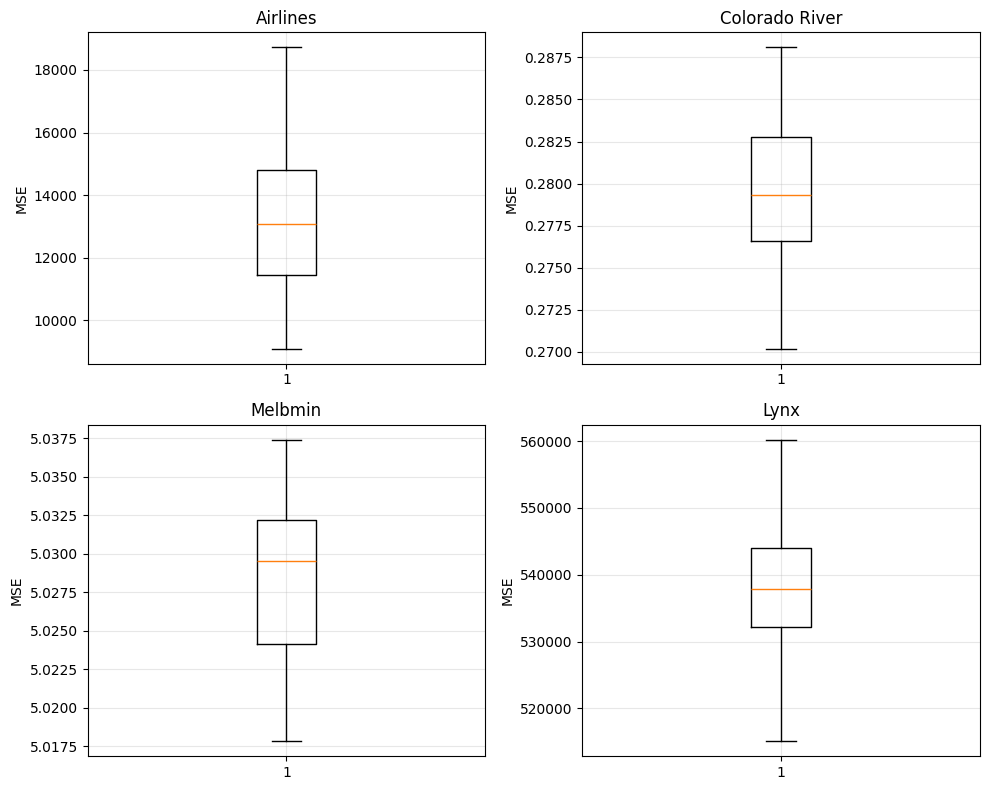

In [216]:
datasets = [
    "airlines.txt",
    "coloradoRiver.txt",
    "melbmin.txt",
    "lynx.txt"
]

titles = [
    "Airlines",
    "Colorado River",
    "Melbmin",
    "Lynx"
]

fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes = axes.flatten()

for ax, dataset, title in zip(axes, datasets, titles):

    dados = df_ga[df_ga["Dataset"] == dataset]["MSE"]

    ax.boxplot(dados)

    ax.set_title(title)

    ax.set_ylabel("MSE")

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "ga_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

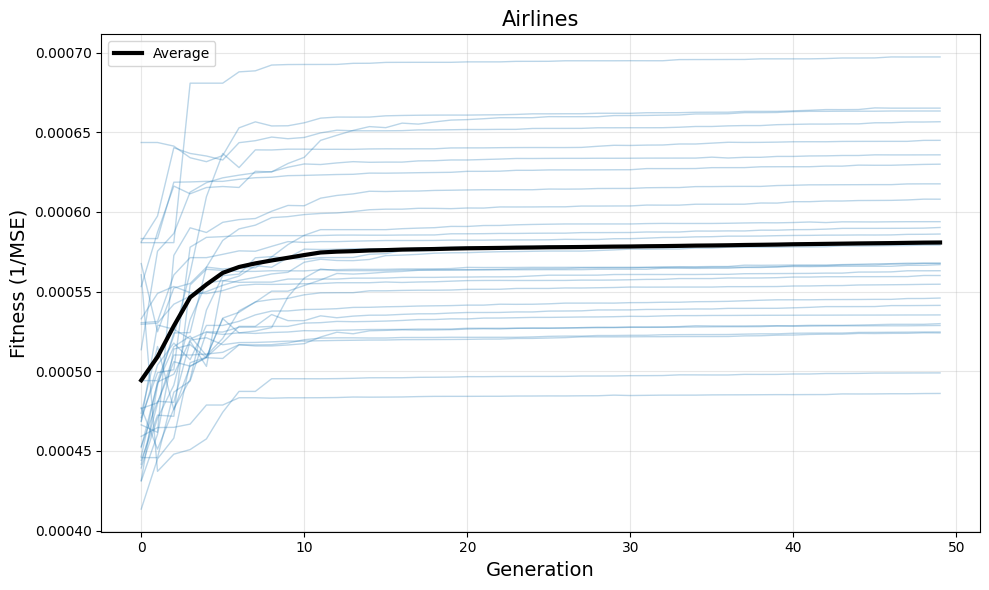

In [186]:
# Curvas de fitness airlines
dataset = "airlines.txt"

fitness_curves = np.array([
    run["Fitness_Curve"]
    for run in ga_runs
    if run["Dataset"] == dataset
])

# Média por geração
mean_curve = fitness_curves.mean(axis=0)

plt.figure(figsize=(10, 6))

# Cada execução (linhas azuis)
for curve in fitness_curves:
    plt.plot(curve,
             color='tab:blue',
             alpha=0.30,
             linewidth=1)

# Média (linha preta)
plt.plot(mean_curve,
         color='black',
         linewidth=3,
         label='Average')

plt.xlabel("Generation", fontsize=14)
plt.title("Airlines", fontsize=15)
plt.ylabel("Fitness (1/MSE)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

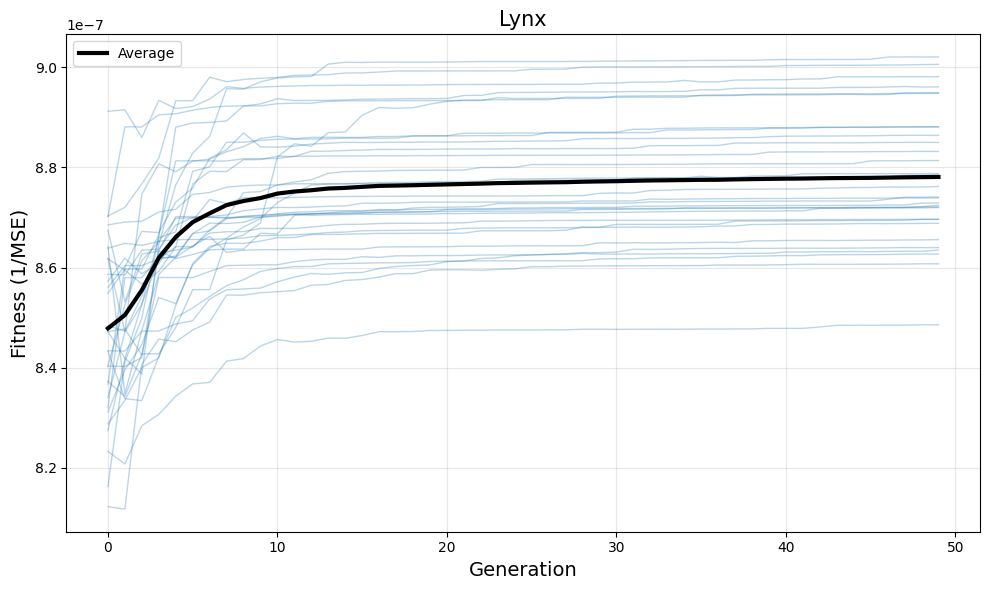

In [187]:
# Curvas de fitness Lynx
dataset = "lynx.txt"

fitness_curves = np.array([
    run["Fitness_Curve"]
    for run in ga_runs
    if run["Dataset"] == dataset
])

# Média por geração
mean_curve = fitness_curves.mean(axis=0)

plt.figure(figsize=(10, 6))

# Cada execução (linhas azuis)
for curve in fitness_curves:
    plt.plot(curve,
             color='tab:blue',
             alpha=0.30,
             linewidth=1)

# Média (linha preta)
plt.plot(mean_curve,
         color='black',
         linewidth=3,
         label='Average')

plt.xlabel("Generation", fontsize=14)
plt.title("Lynx", fontsize=15)
plt.ylabel("Fitness (1/MSE)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

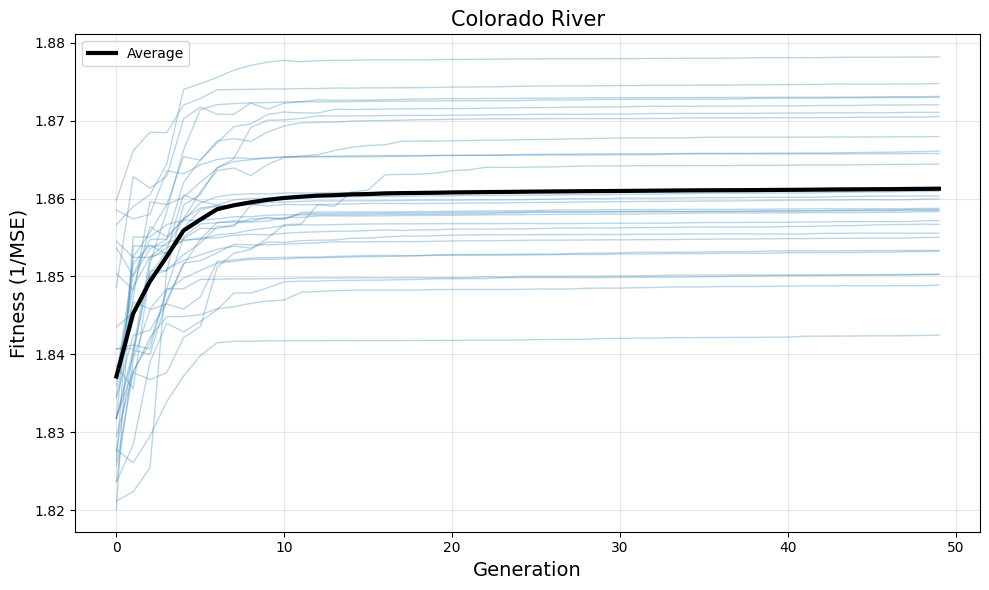

In [188]:
# Curvas de fitness coloradoRiver
dataset = "coloradoRiver.txt"

fitness_curves = np.array([
    run["Fitness_Curve"]
    for run in ga_runs
    if run["Dataset"] == dataset
])

# Média por geração
mean_curve = fitness_curves.mean(axis=0)

plt.figure(figsize=(10, 6))

# Cada execução (linhas azuis)
for curve in fitness_curves:
    plt.plot(curve,
             color='tab:blue',
             alpha=0.30,
             linewidth=1)

# Média (linha preta)
plt.plot(mean_curve,
         color='black',
         linewidth=3,
         label='Average')

plt.xlabel("Generation", fontsize=14)
plt.title("Colorado River", fontsize=15)
plt.ylabel("Fitness (1/MSE)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

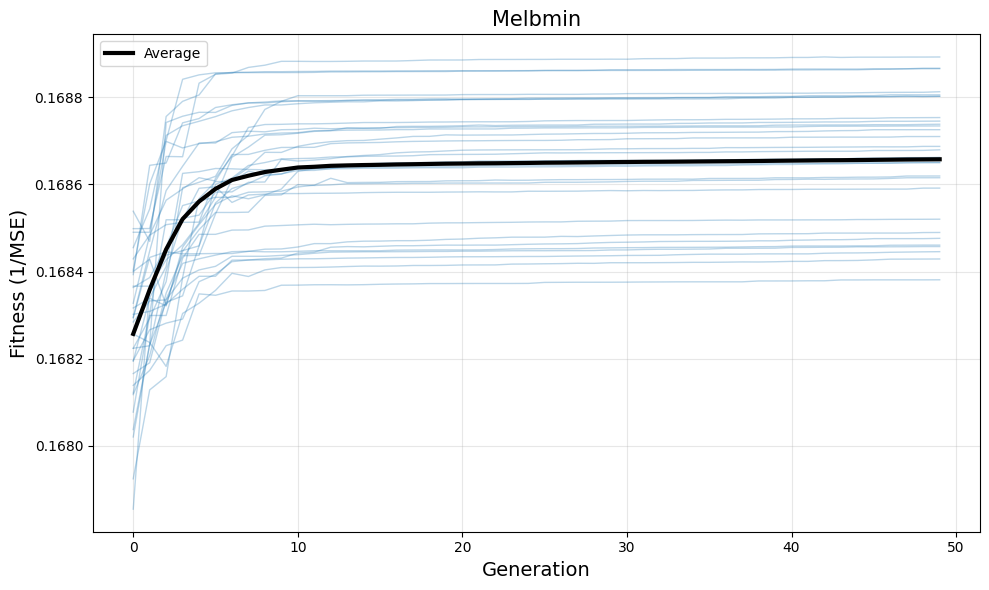

In [189]:
# Curvas de fitness melbmin
dataset = "melbmin.txt"

fitness_curves = np.array([
    run["Fitness_Curve"]
    for run in ga_runs
    if run["Dataset"] == dataset
])

# Média por geração
mean_curve = fitness_curves.mean(axis=0)

plt.figure(figsize=(10, 6))

# Cada execução (linhas azuis)
for curve in fitness_curves:
    plt.plot(curve,
             color='tab:blue',
             alpha=0.30,
             linewidth=1)

# Média (linha preta)
plt.plot(mean_curve,
         color='black',
         linewidth=3,
         label='Average')

plt.xlabel("Generation", fontsize=14)
plt.title("Melbmin", fontsize=15)
plt.ylabel("Fitness (1/MSE)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

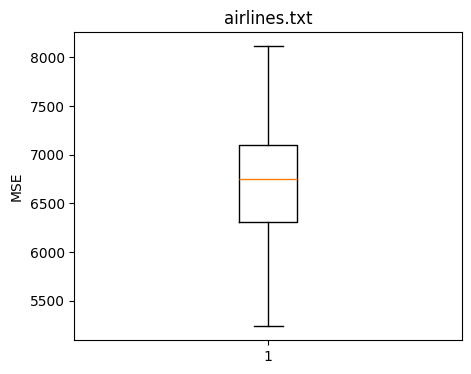

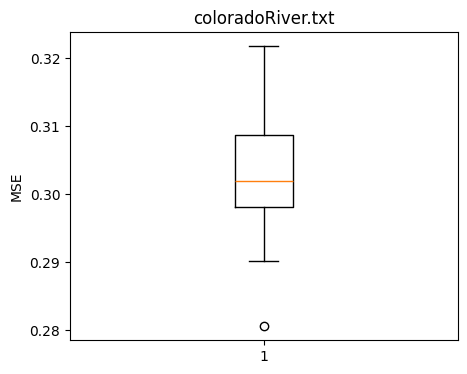

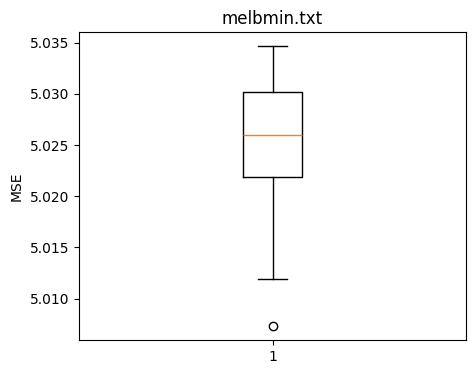

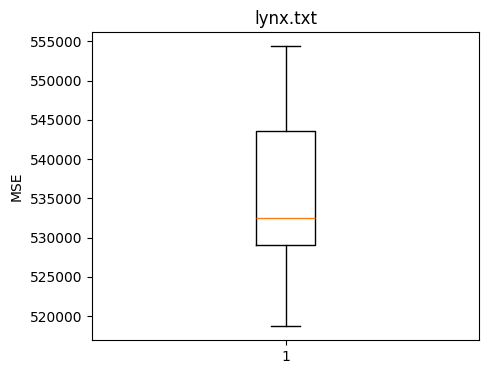

In [190]:
# Boxplot de Dispersão

for dataset in df_ga['Dataset'].unique():
    plt.figure(figsize=(5,4))
    dados = df_ga[df_ga['Dataset']==dataset]['MSE']
    plt.boxplot(dados)
    plt.title(dataset)
    plt.ylabel("MSE")
    plt.show()

In [191]:
# Friedman

friedman_df = df_metrics.pivot(
    index='Dataset',
    columns='Model',
    values='MSE'

)

In [192]:
friedman_df

Model,ELM,EMEAN,GA,GB,MLP,RF,SCN,SVR
Dataset,,,,,,,,
airlines.txt,12904.459955,10684.763520,5504.472033,20154.553053,3677.685524,22154.295907,9987.232411,15222.424587
coloradoRiver.txt,0.349627,0.301423,0.309883,0.374943,0.297891,0.477933,0.441940,0.315603
lynx.txt,521804.345742,572332.010945,523823.614018,832223.417711,553054.971571,632859.165130,577849.798293,1615895.979524
melbmin.txt,5.129966,5.008401,5.033407,5.211832,5.121536,5.045595,5.042219,5.078260


In [193]:
friedmanchisquare(

friedman_df['MLP'],
friedman_df['SCN'],
friedman_df['ELM'],
friedman_df['SVR'],
friedman_df['RF'],
friedman_df['GB'],
friedman_df['EMEAN'],
friedman_df['GA']
)

FriedmanchisquareResult(statistic=np.float64(15.333333333333329), pvalue=np.float64(0.03195618767808722))

In [194]:
nemenyi = sp.posthoc_nemenyi_friedman(
    friedman_df.values
)
nemenyi.index = friedman_df.columns
nemenyi.columns = friedman_df.columns

In [195]:
nemenyi

Model,ELM,EMEAN,GA,GB,MLP,RF,SCN,SVR
Model,,,,,,,,
ELM,1.000000,0.973060,0.899562,0.837013,0.973060,0.944413,1.000000,0.996387
EMEAN,0.973060,1.000000,0.999992,0.215662,1.000000,0.373136,0.973060,0.666146
GA,0.899562,0.999992,1.000000,0.110081,0.999992,0.215662,0.899562,0.467650
GB,0.837013,0.215662,0.110081,1.000000,0.215662,0.999992,0.837013,0.996387
MLP,0.973060,1.000000,0.999992,0.215662,1.000000,0.373136,0.973060,0.666146
RF,0.944413,0.373136,0.215662,0.999992,0.373136,1.000000,0.944413,0.999872
SCN,1.000000,0.973060,0.899562,0.837013,0.973060,0.944413,1.000000,0.996387
SVR,0.996387,0.666146,0.467650,0.996387,0.666146,0.999872,0.996387,1.000000


In [196]:
ranks = friedman_df.rank(axis=1, ascending=True)
avg_ranks = ranks.mean(axis=0)
avg_ranks

,0
Model,
ELM,4.500000
EMEAN,2.750000
GA,2.250000
GB,7.000000
MLP,2.750000
RF,6.500000
SCN,4.500000
SVR,5.750000


{'markers': [<matplotlib.collections.PathCollection at 0x7faa20143350>,
 'elbows': [<matplotlib.lines.Line2D at 0x7faa202799d0>,
 'labels': [Text(2.24, -2, 'GA (2.2)'),
  Text(2.24, -3, 'EMEAN (2.8)'),
  Text(2.24, -4, 'MLP (2.8)'),
  Text(2.24, -5, 'ELM (4.5)'),
  Text(7.01, -2, '(7) GB'),
  Text(7.01, -3, '(6.5) RF'),
  Text(7.01, -4, '(5.8) SVR'),
  Text(7.01, -5, '(4.5) SCN')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x7faa4c09c440>]]}

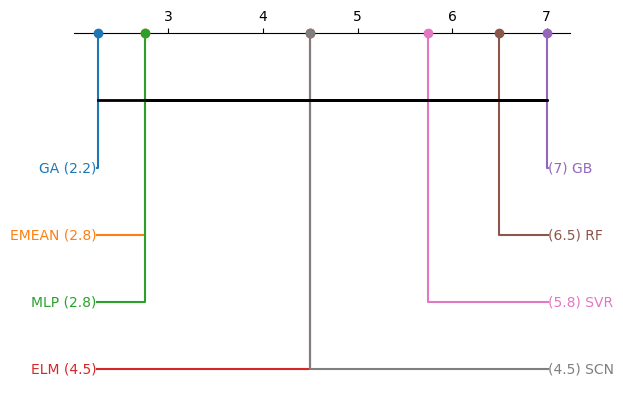

In [197]:
from scikit_posthocs import critical_difference_diagram

critical_difference_diagram(
    avg_ranks,
    nemenyi
)

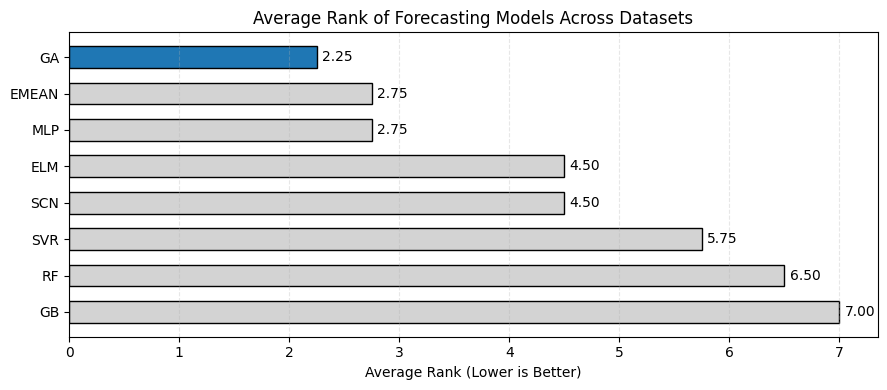

In [198]:
avg_rank = (
    df_rank
    .groupby('Model')['Rank']
    .mean()
    .sort_values()
)

# Todos com Cinza
colors = ['lightgray'] * len(avg_rank)

# GA destaque
ga_idx = avg_rank.index.get_loc('GA')
colors[ga_idx] = 'tab:blue'

fig, ax = plt.subplots(figsize=(9,4))

bars = ax.barh(
    avg_rank.index,
    avg_rank.values,
    color=colors,
    edgecolor='black',
    height=0.6
)

ax.invert_yaxis()

ax.set_xlabel("Average Rank (Lower is Better)")
ax.set_title("Average Rank of Forecasting Models Across Datasets")

ax.grid(axis='x', linestyle='--', alpha=0.3)

for bar in bars:
    ax.text(
        bar.get_width()+0.05,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va='center'
    )

plt.tight_layout()
plt.show()